sample_data2: (200, 19)
registry-individual-data: (200, 17)
Combined dataset shape: (400, 22)

Income raw values:
income
0_5000        284
5001_10000    108
10000_plus      8
Name: count, dtype: int64

Vehicles raw values:
vehicles_owned
two_wheeler      198
bicycle          122
four_wheeler      46
three_wheeler     34
Name: count, dtype: int64

Target distribution:
is_suspicious
1    273
0    127
Name: count, dtype: int64

Missing values in final features:
gender                  0
age                     0
income                  0
household_size          0
nb_children             0
vehicles_owned          0
dependency_ratio        0
income_per_person       0
disability_flag         0
immigration_flag        0
own_home_flag           0
shared_phone_count      0
shared_account_count    0
is_suspicious           0
dtype: int64

Preview:
   gender   age  income  household_size  nb_children  vehicles_owned  \
0       1  51.7   100.0             9.0          7.0             4.0   
1     

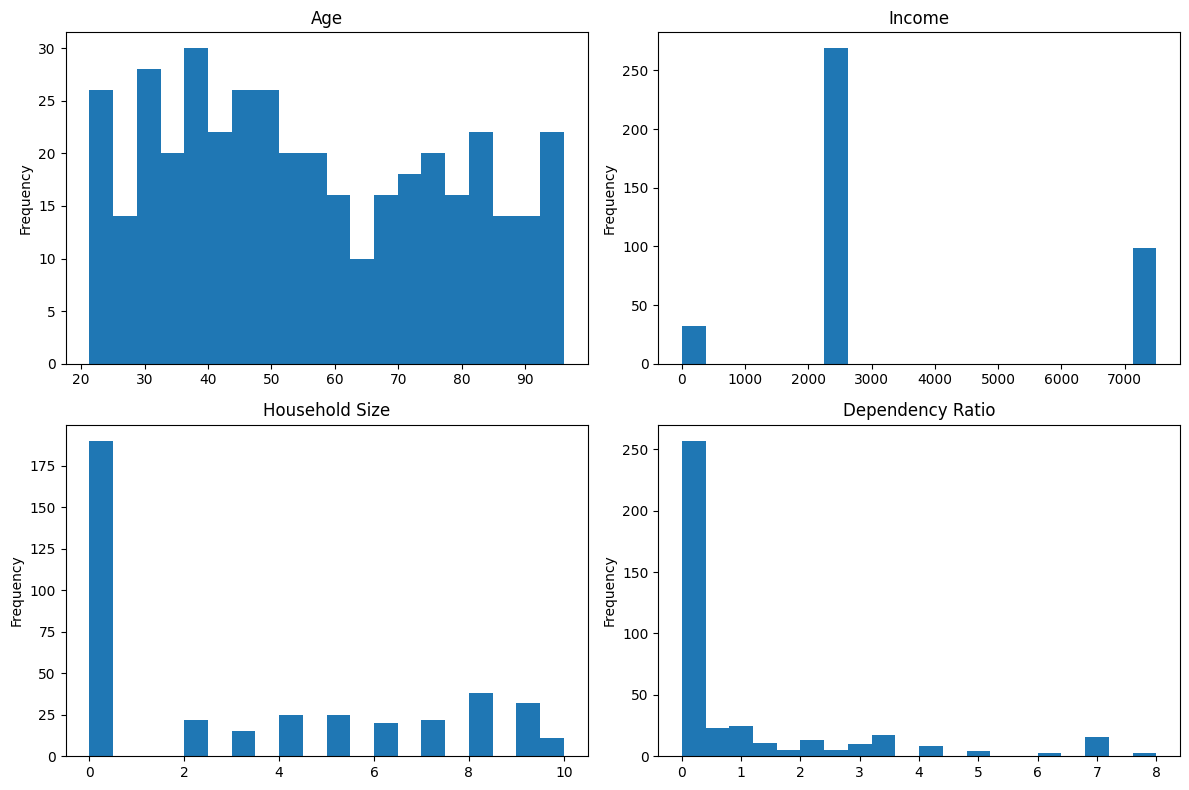


Saved: data/dataset_v2_clean.csv


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1) LOAD DATA
# =========================================================
sample_df = pd.read_csv("data/data/sample_data2.csv")
registry_df = pd.read_csv("data/data/registry-individual-data.csv")

print("sample_data2:", sample_df.shape)
print("registry-individual-data:", registry_df.shape)

# =========================================================
# 2) RENAME COLUMNS
# =========================================================
sample_df = sample_df.rename(columns={
    "Household Id": "household_id",
    "Household size": "household_size",
    "No. of children": "nb_children",
    "Own home?": "own_home",
    "Size of home (sq. ft)": "home_size_sqft",
    "Employement status": "employment_status",
    "Annual household income (USD)": "income",
    "Vehicles owned": "vehicles_owned",
    "UIN": "uin",
    "Full name": "full_name",
    "Date of birth": "date_of_birth",
    "Account number": "account_number",
    "Phone number": "phone_number",
    "Email id": "email",
    "Address": "address",
    "Disability status": "disability_status",
    "Immigration status": "immigration_status",
    "Token ID": "token_id",
    "Gender": "gender"
})

registry_df = registry_df.rename(columns={
    "Registrant ID": "registrant_id",
    "ID": "uin",
    "Token ID": "token_id",
    "Full Name": "full_name",
    "Date of Birth": "date_of_birth",
    "Email ID": "email",
    "Address": "address",
    "Region": "region",
    "Phone Number": "phone_number",
    "Gender": "gender",
    "Home Owned": "own_home",
    "Employement Status": "employment_status",
    "Annual Household Income (USD)": "income",
    "Vehicles Owned": "vehicles_owned",
    "Account Number": "account_number",
    "Disability Status": "disability_status",
    "Immigration Status": "immigration_status"
})

# =========================================================
# 3) ALIGN SCHEMA
# =========================================================
common_cols = [
    "household_id",
    "registrant_id",
    "uin",
    "token_id",
    "full_name",
    "date_of_birth",
    "gender",
    "phone_number",
    "account_number",
    "email",
    "address",
    "own_home",
    "employment_status",
    "income",
    "vehicles_owned",
    "disability_status",
    "immigration_status",
    "household_size",
    "nb_children",
    "home_size_sqft",
    "region"
]

for col in common_cols:
    if col not in sample_df.columns:
        sample_df[col] = np.nan
    if col not in registry_df.columns:
        registry_df[col] = np.nan

sample_df = sample_df[common_cols].copy()
registry_df = registry_df[common_cols].copy()

sample_df["source"] = "sample_data2"
registry_df["source"] = "registry_individual"

# =========================================================
# 4) CONCAT DATA
# =========================================================
df = pd.concat([sample_df, registry_df], ignore_index=True)
print("Combined dataset shape:", df.shape)

# =========================================================
# 5) CLEAN DATES
# =========================================================
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce", dayfirst=True)
df["age"] = ((pd.Timestamp.today() - df["date_of_birth"]).dt.days / 365.25).round(1)

# =========================================================
# 6) MAP CATEGORICAL INCOME TO NUMERIC
# =========================================================
print("\nIncome raw values:")
print(df["income"].value_counts(dropna=False).head(20))

income_map = {
    "0_5000": 2500,
    "5001_10000": 7500,
    "10001_15000": 12500,
    "15001_20000": 17500,
    "20001_25000": 22500,
    "25001_50000": 37500,
    "50001_100000": 75000
}

df["income"] = df["income"].replace(income_map)
df["income"] = pd.to_numeric(df["income"], errors="coerce")

# =========================================================
# 7) MAP VEHICLES TO NUMERIC
# =========================================================
print("\nVehicles raw values:")
print(df["vehicles_owned"].value_counts(dropna=False).head(20))

vehicle_map = {
    "none": 0,
    "bicycle": 1,
    "two_wheeler": 2,
    "four_wheeler": 4
}

df["vehicles_owned"] = df["vehicles_owned"].replace(vehicle_map)
df["vehicles_owned"] = pd.to_numeric(df["vehicles_owned"], errors="coerce")

# =========================================================
# 8) NUMERIC CONVERSIONS
# =========================================================
for col in ["household_size", "nb_children", "home_size_sqft"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================================================
# 9) CLEAN TEXT COLUMNS
# =========================================================
text_cols = [
    "gender",
    "phone_number",
    "account_number",
    "employment_status",
    "disability_status",
    "immigration_status",
    "own_home"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Replace fake missing values
df.loc[df["phone_number"].isin(["nan", "None", ""]), "phone_number"] = np.nan
df.loc[df["account_number"].isin(["nan", "None", ""]), "account_number"] = np.nan

# =========================================================
# 10) FLAGS
# =========================================================
df["disability_flag"] = (
    df["disability_status"]
    .astype(str)
    .str.lower()
    .isin(["yes", "true", "1", "disabled", "has_disability"])
    .astype(int)
)

df["immigration_flag"] = (
    df["immigration_status"]
    .astype(str)
    .str.lower()
    .isin(["yes", "true", "1", "immigrant", "migrant"])
    .astype(int)
)

df["own_home_flag"] = (
    df["own_home"]
    .astype(str)
    .str.lower()
    .isin(["yes", "true", "1", "owned", "own_home"])
    .astype(int)
)

# =========================================================
# 11) BASE FEATURES
# =========================================================
df["nb_adults"] = df["household_size"] - df["nb_children"]
df["nb_adults"] = df["nb_adults"].clip(lower=0)

df["dependency_ratio"] = df["nb_children"] / df["nb_adults"].replace(0, np.nan)
df["dependency_ratio"] = df["dependency_ratio"].fillna(0)

df["income_per_person"] = df["income"] / df["household_size"].replace(0, np.nan)
df["income_per_person"] = df["income_per_person"].fillna(0)

# =========================================================
# 12) NETWORK SIGNALS BEFORE SYNTHETIC FRAUD
# =========================================================
phone_counts = df.groupby("phone_number")["phone_number"].transform("count")
account_counts = df.groupby("account_number")["account_number"].transform("count")

df["shared_phone_count"] = phone_counts.fillna(1)
df["shared_account_count"] = account_counts.fillna(1)

df["shared_phone_flag"] = (df["shared_phone_count"] >= 3).astype(int)
df["shared_account_flag"] = (df["shared_account_count"] >= 3).astype(int)

# =========================================================
# 13) CREATE SYNTHETIC SUSPICIOUS CASES
# =========================================================
df_v2 = df.copy()
np.random.seed(42)
suspect_idx = df_v2.sample(frac=0.15, random_state=42).index

# Group 1: same phone
df_v2.loc[suspect_idx[:12], "phone_number"] = "PHONE-FRAUD-001"

# Group 2: same account
df_v2.loc[suspect_idx[12:24], "account_number"] = "ACC-FRAUD-001"

# Group 3: large household + very low income
df_v2.loc[suspect_idx[24:36], "income"] = 100
df_v2.loc[suspect_idx[24:36], "household_size"] = 9
df_v2.loc[suspect_idx[24:36], "nb_children"] = 7

# Group 4: low income + many vehicles
df_v2.loc[suspect_idx[36:48], "income"] = 120
df_v2.loc[suspect_idx[36:48], "vehicles_owned"] = 4

# Group 5: extreme dependency ratio
df_v2.loc[suspect_idx[48:60], "household_size"] = 8
df_v2.loc[suspect_idx[48:60], "nb_children"] = 7

# =========================================================
# 14) RECALCULATE FEATURES AFTER SYNTHETIC CHANGES
# =========================================================
df_v2["nb_adults"] = df_v2["household_size"] - df_v2["nb_children"]
df_v2["nb_adults"] = df_v2["nb_adults"].clip(lower=0)

df_v2["dependency_ratio"] = df_v2["nb_children"] / df_v2["nb_adults"].replace(0, np.nan)
df_v2["dependency_ratio"] = df_v2["dependency_ratio"].fillna(0)

df_v2["income_per_person"] = df_v2["income"] / df_v2["household_size"].replace(0, np.nan)
df_v2["income_per_person"] = df_v2["income_per_person"].fillna(0)

phone_counts = df_v2.groupby("phone_number")["phone_number"].transform("count")
account_counts = df_v2.groupby("account_number")["account_number"].transform("count")

df_v2["shared_phone_count"] = phone_counts.fillna(1)
df_v2["shared_account_count"] = account_counts.fillna(1)

df_v2["shared_phone_flag"] = (df_v2["shared_phone_count"] >= 3).astype(int)
df_v2["shared_account_flag"] = (df_v2["shared_account_count"] >= 3).astype(int)

# =========================================================
# 15) TARGET
# =========================================================
df_v2["is_suspicious"] = (
    (df_v2["shared_phone_count"] >= 3) |
    (df_v2["shared_account_count"] >= 3) |
    (df_v2["dependency_ratio"] >= 3) |
    (df_v2["income_per_person"] < 100) |
    ((df_v2["income"] < 500) & (df_v2["vehicles_owned"] >= 3))
).astype(int)

# =========================================================
# 16) ENCODE GENDER
# =========================================================
df_v2["gender"] = df_v2["gender"].astype(str).str.lower()
df_v2["gender"] = df_v2["gender"].map({"male": 0, "female": 1}).fillna(0)

# =========================================================
# 17) FINAL FEATURE LIST
# =========================================================
final_features = [
    "gender",
    "age",
    "income",
    "household_size",
    "nb_children",
    "vehicles_owned",
    "dependency_ratio",
    "income_per_person",
    "disability_flag",
    "immigration_flag",
    "own_home_flag",
    "shared_phone_count",
    "shared_account_count"
]

target = "is_suspicious"

# Fill remaining NaN in final features
df_v2[final_features] = df_v2[final_features].fillna(0)

# =========================================================
# 18) CHECKS
# =========================================================
print("\nTarget distribution:")
print(df_v2["is_suspicious"].value_counts())

print("\nMissing values in final features:")
print(df_v2[final_features + [target]].isna().sum())

print("\nPreview:")
print(df_v2[final_features + [target]].head())

print("\nDataset shape:")
print(df_v2.shape)

# =========================================================
# 19) QUICK VISUAL CHECKS
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df_v2["age"].plot(kind="hist", bins=20, ax=axes[0, 0], title="Age")
df_v2["income"].plot(kind="hist", bins=20, ax=axes[0, 1], title="Income")
df_v2["household_size"].plot(kind="hist", bins=20, ax=axes[1, 0], title="Household Size")
df_v2["dependency_ratio"].plot(kind="hist", bins=20, ax=axes[1, 1], title="Dependency Ratio")

plt.tight_layout()
plt.show()

# =========================================================
# 20) SAVE CLEAN DATASET
# =========================================================
df_v2.to_csv("data/dataset_v2_clean.csv", index=False)
print("\nSaved: data/dataset_v2_clean.csv")

Dataset shape: (400, 34)
   household_id  registrant_id         uin  \
0  8.660131e+09            NaN  9937286382   
1  8.383206e+09            NaN  7675948129   
2  9.576486e+09            NaN  3112264971   
3  1.651192e+09            NaN  2865414427   
4  2.002736e+09            NaN  7531321987   

                               token_id                full_name  \
0  068130455742399305784829962633186139  Maria Cristina Gonzales   
1  850304202715624296041166059049263792       Juan Carlos Santos   
2  245388731738822991142974328199577296           Angelica Reyes   
3  944050462013912686120363288879302103       Jose Manuel Garcia   
4  850496652659689460177344664014412565            Marianne Cruz   

  date_of_birth  gender     phone_number account_number                email  \
0    1974-07-01       1  +745 5218119193     1717875761     maria@myland.com   
1    1947-06-18       1  +745 9921926785     5993556155      juan@myland.com   
2    1960-03-27       0  +745 3378765413     3137

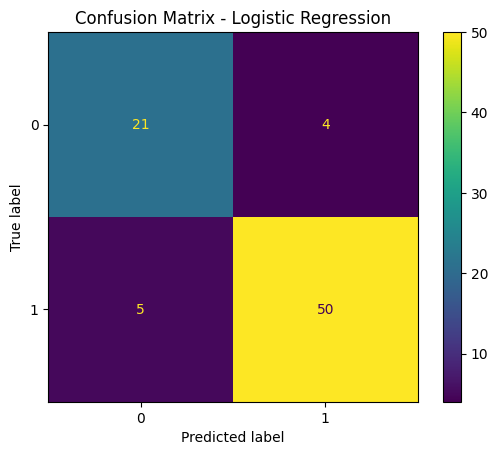


================ RANDOM FOREST ================
Accuracy : 0.975
Precision: 1.0
Recall   : 0.9636363636363636
F1-score : 0.9814814814814815

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        25
           1       1.00      0.96      0.98        55

    accuracy                           0.97        80
   macro avg       0.96      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



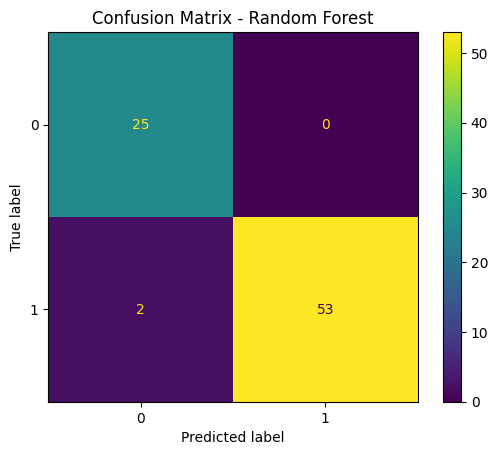


================ MODEL COMPARISON ================
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression    0.8875   0.925926  0.909091  0.917431
1        Random Forest    0.9750   1.000000  0.963636  0.981481


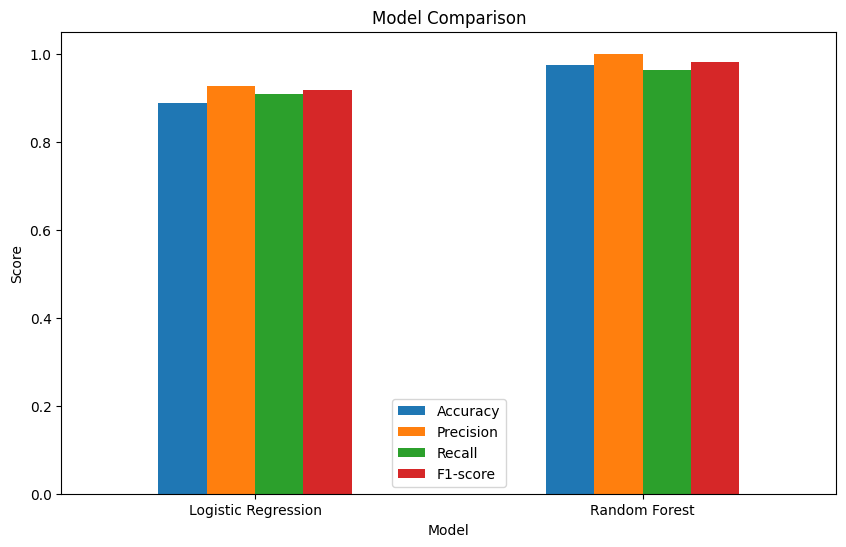


================ FEATURE IMPORTANCE (RF) ================
                 feature  importance
7      income_per_person    0.315694
6       dependency_ratio    0.239565
3         household_size    0.187754
4            nb_children    0.122155
12  shared_account_count    0.031452
1                    age    0.031135
2                 income    0.028684
11    shared_phone_count    0.016892
5         vehicles_owned    0.011877
0                 gender    0.005440
10         own_home_flag    0.005290
8        disability_flag    0.003731
9       immigration_flag    0.000332


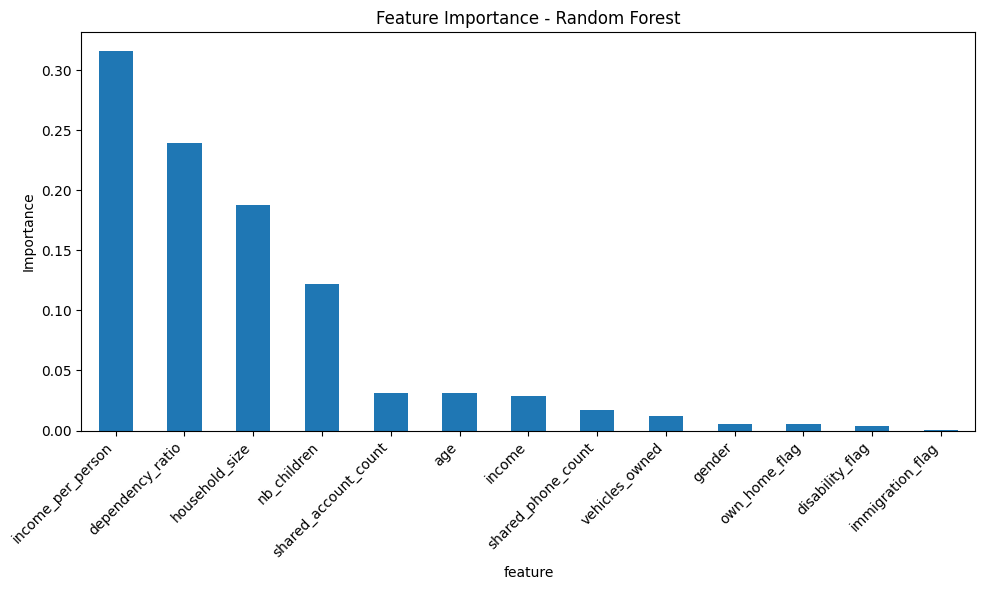


================ LOGISTIC COEFFICIENTS ================
                 feature  coefficient
6       dependency_ratio     2.643329
12  shared_account_count     1.659642
5         vehicles_owned     1.251831
11    shared_phone_count     0.768247
0                 gender     0.330776
10         own_home_flag     0.201129
9       immigration_flag     0.110397
1                    age     0.002615
2                 income     0.000666
7      income_per_person    -0.007159
8        disability_flag    -0.091195
4            nb_children    -0.277318
3         household_size    -0.918618


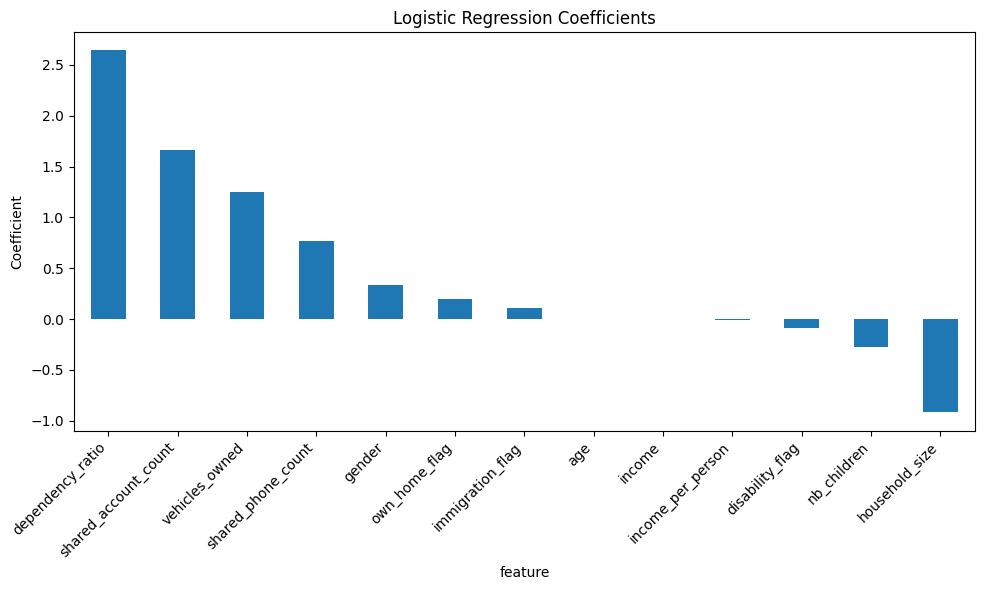

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# 1) LOAD CLEAN DATASET
# =========================================================
df = pd.read_csv("data/dataset_v2_clean.csv")

print("Dataset shape:", df.shape)
print(df.head())

# =========================================================
# 2) DEFINE FEATURES AND TARGET
# =========================================================
features = [
    "gender",
    "age",
    "income",
    "household_size",
    "nb_children",
    "vehicles_owned",
    "dependency_ratio",
    "income_per_person",
    "disability_flag",
    "immigration_flag",
    "own_home_flag",
    "shared_phone_count",
    "shared_account_count"
]

target = "is_suspicious"

X = df[features].copy()
y = df[target].copy()

print("\nTarget distribution:")
print(y.value_counts())

# =========================================================
# 3) FINAL SAFETY CHECK
# =========================================================
print("\nMissing values in X:")
print(X.isna().sum())

X = X.fillna(0)

# =========================================================
# 4) TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================================================
# 5) LOGISTIC REGRESSION
# =========================================================
log_model = LogisticRegression(max_iter=2500)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n================ LOGISTIC REGRESSION ================")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1-score :", f1_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# Confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# =========================================================
# 6) RANDOM FOREST
# =========================================================
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n================ RANDOM FOREST ================")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# =========================================================
# 7) COMPARE MODELS
# =========================================================
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

print("\n================ MODEL COMPARISON ================")
print(results)

# Optional bar chart comparison
results_plot = results.set_index("Model")
results_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# =========================================================
# 8) FEATURE IMPORTANCE - RANDOM FOREST
# =========================================================
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n================ FEATURE IMPORTANCE (RF) ================")
print(feature_importance)

feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(10, 6),
    legend=False
)
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# =========================================================
# 9) LOGISTIC REGRESSION COEFFICIENTS
# =========================================================
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": log_model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

print("\n================ LOGISTIC COEFFICIENTS ================")
print(coef_df)

coef_df.plot(
    x="feature",
    y="coefficient",
    kind="bar",
    figsize=(10, 6),
    legend=False
)
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()




================ XGBOOST ================
Accuracy : 0.975
Precision: 1.0
Recall   : 0.9636363636363636
F1-score : 0.9814814814814815

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        25
           1       1.00      0.96      0.98        55

    accuracy                           0.97        80
   macro avg       0.96      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



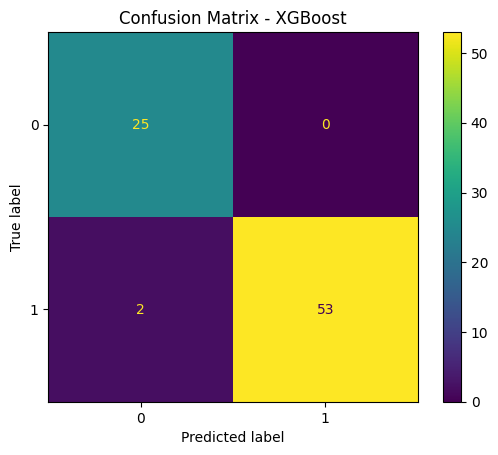

In [125]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# XGBOOST
# =========================================================
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\n================ XGBOOST ================")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()


================ MODEL COMPARISON ================
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression    0.8875   0.925926  0.909091  0.917431
1        Random Forest    0.9750   1.000000  0.963636  0.981481
2              XGBoost    0.9750   1.000000  0.963636  0.981481


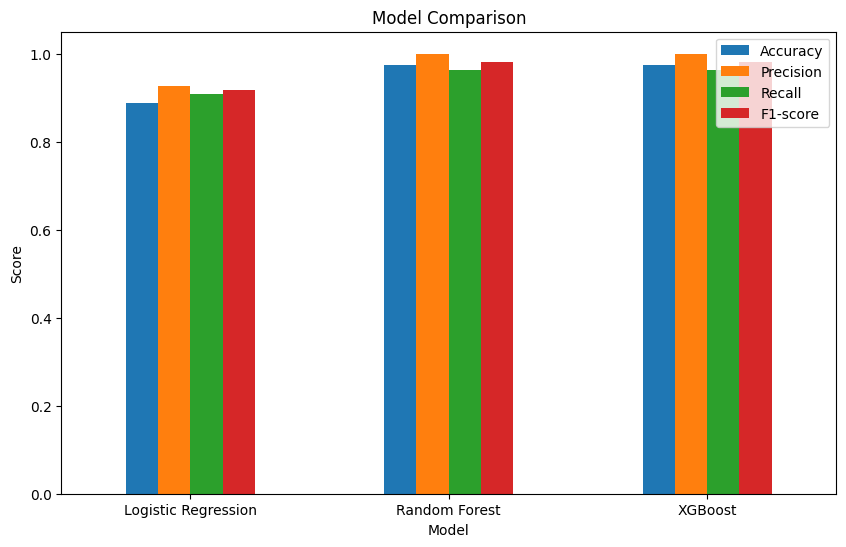

In [126]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

print("\n================ MODEL COMPARISON ================")
print(results)

results_plot = results.set_index("Model")
results_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


================ FEATURE IMPORTANCE (XGBOOST) ================
                 feature  importance
7      income_per_person    0.347008
6       dependency_ratio    0.203535
12  shared_account_count    0.167127
2                 income    0.131327
3         household_size    0.086727
4            nb_children    0.037168
1                    age    0.008275
0                 gender    0.007519
10         own_home_flag    0.005689
5         vehicles_owned    0.005625
8        disability_flag    0.000000
9       immigration_flag    0.000000
11    shared_phone_count    0.000000


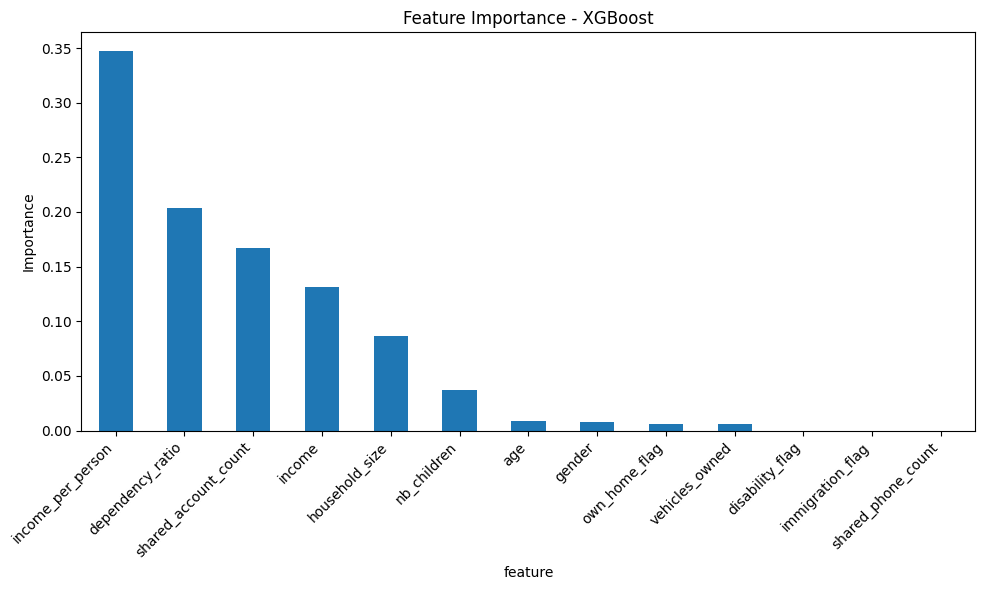

In [127]:
xgb_importance = pd.DataFrame({
    "feature": features,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n================ FEATURE IMPORTANCE (XGBOOST) ================")
print(xgb_importance)

xgb_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(10, 6),
    legend=False
)
plt.title("Feature Importance - XGBoost")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()